# Week 3 — Day 1  
**Θέμα:** Binary Classification (Logistic Regression) + Regularization + Metrics

## 🎯 Στόχοι notebook
- Εκπαίδευση baseline `LogisticRegression` σε **70/30 stratified split**.  
- Pipeline: `StandardScaler` → `LogisticRegression(class_weight="balanced")`.  
- Αξιολόγηση με **Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC**.  
- Οπτικοποίηση με **ROC curve**, **PR curve** και **Confusion Matrix**.

---

### Γιατί αυτές οι επιλογές;

**Stratified split (70/30):**  
Στα credit card fraud datasets η κλάση *fraud* είναι εξαιρετικά σπάνια. Το `stratify=y` εξασφαλίζει ότι το train και test set έχουν ίδια αναλογία θετικών/αρνητικών.

**Pipeline (Scaler → Logistic Regression):**  
- Το `StandardScaler` φέρνει όλα τα features σε κοινή κλίμακα (0 mean, unit variance).  
- Το `class_weight="balanced"` αναγκάζει το μοντέλο να δίνει βάρος και στη μειοψηφική κλάση (fraud).  
- Το `Pipeline` αποτρέπει **data leakage**: fit στο train μόνο, transform σε test.

**Μετρικές:**  
- Accuracy → μπορεί να παραπλανήσει (υψηλό λόγω πολλών TN).  
- Precision → focus στα false positives.  
- Recall → focus στα false negatives (προτεραιότητα στο fraud detection).  
- F1 → ισορροπία Precision/Recall.  
- ROC-AUC → συνολική ικανότητα διάκρισης.  
- PR-AUC → πιο κατατοπιστικό σε **imbalanced datasets**.

**Plots:**  
- ROC curve → trade-off TPR vs FPR.  
- PR curve → trade-off Precision vs Recall (ιδανικό για rare events).  
- Confusion Matrix → snapshot στο default threshold (0.5).  

---


In [29]:

# -------------------- Imports --------------------
from pathlib import Path                 # Διαχείριση διαδρομών αρχείων (cross-platform)
import pandas as pd                      # Διαχείριση/ανάλυση δεδομένων (DataFrame)
import numpy as np                       # Αριθμητικές πράξεις, arrays, βοηθητικά
import matplotlib.pyplot as plt          # Γραφήματα / οπτικοποίηση

from sklearn.model_selection import train_test_split   # Train/test split (με stratify)
from sklearn.preprocessing import StandardScaler       # Κανονικοποίηση χαρακτηριστικών (0-mean, unit-variance)
from sklearn.pipeline import make_pipeline             # Δημιουργία pipeline (Scaler → Model) με 1 γραμμή
from sklearn.linear_model import LogisticRegression    # Γραμμικό μοντέλο ταξινόμησης με L2 regularization by default
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,     # Βασικές μετρικές
    roc_auc_score, average_precision_score,                      # Περιοχές καμπυλών ROC/PR (AUC & AP)
    RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay  # Έτοιμες κλάσεις για plots
)

# -------------------- Inline plots --------------------
%matplotlib inline
# Jupyter magic: τα plots εμφανίζονται μέσα στο notebook output, κάτω από το κελί


In [30]:
# -------------------- Paths & Configuration --------------------

from pathlib import Path

# 📂 Dataset path
# ../../ σημαίνει "δύο φακέλους πίσω" από το notebook (week3/day1_logreg_baseline.ipynb).
DATA_PATH = Path("../../data/data_raw/creditcard.csv")

# 📊 Output directories
# - IMAGES_DIR: αποθήκευση plots (ROC/PR curves, confusion matrix κ.ά.)
# - REPORTS_DIR: αποθήκευση αναφορών (CSV/JSON με μετρικές, logs)
IMAGES_DIR = Path("../../reports/figures/week3")
REPORTS_DIR = Path("../../reports/week3_metrics")

# Δημιουργία φακέλων (αν δεν υπάρχουν ήδη).
# parents=True → φτιάχνει και τυχόν ενδιάμεσους φακέλους.
# exist_ok=True → δεν σκάει αν ο φάκελος υπάρχει ήδη.
IMAGES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# 🎯 Target column candidates
# Σε διαφορετικά fraud datasets, το target μπορεί να ονομάζεται διαφορετικά.
# Αυτό επιτρέπει στο notebook να δουλεύει "έξυπνα" χωρίς να χρειάζεται manual αλλαγή.
CANDIDATE_TARGETS = ["Class", "class", "is_fraud", "fraud"]

# -------------------- Utility: Find target column --------------------
def get_target_column(df, candidates=CANDIDATE_TARGETS):
    """
    Επιστρέφει το όνομα της στήλης-στόχου (target) αν υπάρχει στο DataFrame.
    Αν δεν βρεθεί, σηκώνει σφάλμα.

    Parameters
    ----------
    df : pd.DataFrame
        Το dataset
    candidates : list[str]
        Λίστα πιθανών ονομάτων target column

    Returns
    -------
    str : το όνομα της target column
    """
    for col in candidates:
        if col in df.columns:
            return col
    raise ValueError(
        f"❌ Target column not found. Candidates tried: {candidates}\n"
        f"Available columns: {list(df.columns)}"
    )



In [31]:
# -------------------- Load dataset (robust) --------------------

# Paths από το προηγούμενο κελί:
# DATA_PATH, CANDIDATE_TARGETS = [...]

# 1) Έλεγχος ύπαρξης αρχείου
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"❌ Λείπει το {DATA_PATH}.\n"
        "➡ Βάλε το CSV στο data/data_raw/ ή άλλαξε το DATA_PATH."
    )

# 2) Φόρτωμα CSV (με ασφαλέστερες προεπιλογές)
# low_memory=False για να αποφύγεις τύπους 'object' σε αριθμητικές στήλες
# na_values για τυχόν 'NA', 'NaN', '' κ.λπ. (δεν αλλάζει το dataset αν δεν υπάρχουν)
df = pd.read_csv(
    DATA_PATH,
    low_memory=False,
    na_values=["", "NA", "NaN", "null", None]
)

# 3) Εντοπισμός target column
target = next((c for c in CANDIDATE_TARGETS if c in df.columns), None)
if target is None:
    raise ValueError(
        "❌ Δεν βρέθηκε στήλη-στόχος στο DataFrame.\n"
        f"➡ Δοκιμάστηκαν: {CANDIDATE_TARGETS}\n"
        f"📋 Διαθέσιμες στήλες: {list(df.columns)}"
    )

# 4) Αφαίρεση διπλοτύπων (προληπτικά) + reset index
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
removed = before - len(df)
if removed:
    print(f"ℹ️ Αφαιρέθηκαν {removed} διπλότυπες γραμμές.")

# 5) y = target (βεβαιωνόμαστε ότι είναι binary 0/1)
y_raw = df[target].copy()

# Αν ο target είναι float/bool/object, τον κάνουμε 0/1 με ασφάλεια
# (στο creditcard.csv ο 'Class' είναι ήδη {0,1}, απλώς κάνουμε explicit cast)
y = pd.to_numeric(y_raw, errors="raise").astype(int)

# Έλεγχος ότι ο στόχος είναι διτιμικός
unique_y = sorted(pd.unique(y))
if not set(unique_y).issubset({0, 1}):
    raise ValueError(f"❌ Ο στόχος περιέχει τιμές εκτός των 0/1: {unique_y}")

# 6) X = όλα τα features εκτός του target
X = df.drop(columns=[target])

# 7) Γρήγορα sanity checks
# 7a) Αν υπάρχουν μη-αριθμητικές στήλες στα X, τις κρατάμε για ενημέρωση (δεν τις πετάμε εδώ)
non_numeric_cols = X.select_dtypes(exclude=["number"]).columns.tolist()
if non_numeric_cols:
    print(
        "⚠️ Υπάρχουν μη-αριθμητικές στήλες στα features "
        f"(θα χρειαστούν encoding πριν το modeling): {non_numeric_cols}"
    )

# 7b) Έλεγχος για inf / -inf στις αριθμητικές στήλες (π.χ. από log μετασχηματισμούς σε άλλα data)
num_cols = X.select_dtypes(include=["number"]).columns
num_inf_mask = np.isinf(X[num_cols].to_numpy()).any()
if num_inf_mask:
    # Replace inf με NaN και άφησέ τα στο pipeline να τα χειριστεί (imputer) ή ρίξε error αν θες
    X[num_cols] = X[num_cols].replace([np.inf, -np.inf], np.nan)
    print("⚠️ Βρέθηκαν ±∞ σε numeric features → αντικαταστάθηκαν με NaN.")

# 7c) (Προαιρετικό) ενημέρωση για NaN σε X
na_counts = X.isna().sum()
na_total = int(na_counts.sum())
if na_total > 0:
    top_na = na_counts[na_counts > 0].sort_values(ascending=False).head(5)
    print(f"⚠️ Υπάρχουν {na_total} NaN στα features. Πάνω-5 στήλες με NaN:\n{top_na}")

# 8) Εκτυπώσεις ελέγχου
pos_rate = y.mean()  # π.χ. ~0.00173 για το creditcard.csv
print(f"✅ Dataset loaded: shape={df.shape}, target='{target}'")
print(f"   Fraud rate (positives mean): {pos_rate:.6f}  (~{pos_rate*100:.3f}%)")
print("   Head (3 rows):")
display(df.head(3))

# 9) Προαιρετικά: για modeling μόνο αριθμητικά features (στο creditcard είναι όλα numeric ήδη)
# X_num = X.select_dtypes(include=["number"]).copy()
# print(f"Features used (numeric only): {X_num.shape[1]} / {X.shape[1]}")


ℹ️ Αφαιρέθηκαν 1081 διπλότυπες γραμμές.
✅ Dataset loaded: shape=(283726, 31), target='Class'
   Fraud rate (positives mean): 0.001667  (~0.167%)
   Head (3 rows):


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


In [32]:
# -------------------- Train / Test split --------------------

# Χωρίζουμε το dataset σε train (70%) και test (30%).
# - test_size=0.30 -> 30% για test set
# - stratify=y -> κρατάει την ίδια αναλογία κλάσεων (π.χ. fraud vs non-fraud) 
#   τόσο στο train όσο και στο test.
# - random_state=42 -> για αναπαραγωγιμότητα (ίδιο split κάθε φορά που τρέχουμε).
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)
# Ελέγχουμε πόσα δείγματα πήγαν στο train/test (για επιβεβαίωση).
len(X_train), len(X_test)


(198608, 85118)

🔎 Γιατί είναι σημαντικό το stratify=y;

-Σε imbalanced datasets (όπως fraud detection), αν κάνεις split χωρίς stratify, υπάρχει κίνδυνος το test set να έχει ελάχιστα ή ακόμα και μηδενικά fraud cases.
-Με το stratify=y, διατηρείται η ίδια αναλογία θετικών/αρνητικών όπως στο αρχικό dataset. Έτσι:
-Το train set μαθαίνει σωστά και από τις δύο κλάσεις.
-Το test set είναι ρεαλιστικό και αντιπροσωπευτικό.

🔎 Γιατί random_state=42;

-Η τυχαιότητα στο split μπορεί να αλλάξει τα αποτελέσματα (ειδικά όταν η θετική κλάση είναι λίγη).
-Το random_state=42 “παγώνει” την τυχαιότητα → όποιος τρέξει το notebook (εσύ ή στο GitHub), παίρνει το ίδιο split.
-Το 42 είναι απλά μια “παράδοση” στην Python community, μπορεί να είναι οποιοδήποτε int.

In [33]:
# Έλεγχος ισορροπίας μετά το split
print("Train split shape:", X_train.shape, "| Fraud rate:", y_train.mean())
print("Test  split shape:", X_test.shape, "| Fraud rate:", y_test.mean())

summary = pd.DataFrame({
    "set": ["train", "test"],
    "rows": [len(y_train), len(y_test)],
    "fraud_rate": [y_train.mean(), y_test.mean()]
})
display(summary)

Train split shape: (198608, 30) | Fraud rate: 0.0016665995327479256
Test  split shape: (85118, 30) | Fraud rate: 0.0016682722808336662


,set,rows,fraud_rate
0,train,198608,0.001667
1,test,85118,0.001668


In [34]:
# -------------------- Pipeline: StandardScaler -> LogisticRegression --------------------

# Φτιάχνουμε ένα pipeline (σειρά βημάτων) που εκτελείται με μία κλήση fit/predict.
# Το pipeline έχει 2 στάδια:
# 1) StandardScaler: κανονικοποιεί κάθε feature (μέση τιμή = 0, τυπική απόκλιση = 1).
#    Αυτό είναι σημαντικό γιατί η LogisticRegression κάνει L2 regularization
#    και η κλίμακα των χαρακτηριστικών επηρεάζει το optimization.
# 2) LogisticRegression: μοντέλο γραμμικής ταξινόμησης με τις εξής παραμέτρους:
#    - class_weight="balanced": δίνει μεγαλύτερο βάρος στη σπάνια κλάση (fraud),
#      ώστε το μοντέλο να μην αγνοήσει τις λίγες θετικές περιπτώσεις.
#    - max_iter=1000: αυξάνει τον μέγιστο αριθμό επαναλήψεων στο optimization,
#      για να αποφύγουμε warnings "failed to converge".
#    - solver="lbfgs": ο αλγόριθμος optimization (γρήγορος και σταθερός για μεσαίου μεγέθους datasets).
#    - random_state=42: για αναπαραγωγιμότητα (ίδια αποτελέσματα σε κάθε εκτέλεση).

# Ορίζουμε pipeline με scaling + logistic regression
clf = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        solver="lbfgs",
        random_state=42
    )
)

# Εκπαιδεύουμε το pipeline στο training set.
# Το pipeline κάνει αυτόματα:
# - fit_transform(X_train) με το StandardScaler (μαθαίνει μέσους όρους και τυπ. αποκλίσεις από το train)
# - fit(...) με LogisticRegression χρησιμοποιώντας τα scaled δεδομένα.
clf.fit(X_train, y_train)

print("✅ Pipeline trained successfully:")
print("   Steps:", [name for name, _ in clf.steps])

✅ Pipeline trained successfully:
   Steps: ['standardscaler', 'logisticregression']


🔎 Γιατί Pipeline και όχι ξεχωριστά;

Αν έκανες:

> scaler = StandardScaler()
> X_train_scaled = scaler.fit_transform(X_train)
> X_test_scaled = scaler.transform(X_test)

και μετά:

> logreg = LogisticRegression(...)
> logreg.fit(X_train_scaled, y_train)


θα έπρεπε χειροκίνητα να θυμάσαι σε κάθε στάδιο ποιο scaler έκανες fit.

Με το Pipeline:
- Όλα δένονται σε ένα αντικείμενο clf.
- Όταν καλείς clf.fit, εφαρμόζονται με σωστή σειρά.
- Όταν κάνεις clf.predict(X_test), το pipeline ξέρει να κάνει πρώτα scaler.transform και μετά predict.
- Έτσι αποφεύγεις data leakage και έχεις καθαρότερο κώδικα.

In [35]:

# -------------------- Predictions & probabilities --------------------

# Προβλέψεις (0 ή 1) στο test set με βάση το default threshold = 0.5.
y_pred = clf.predict(X_test)

# Πιθανότητες για την κλάση 1 (fraud).
# predict_proba επιστρέφει 2 στήλες: [prob(class=0), prob(class=1)].
# Με [:, 1] παίρνουμε τις πιθανότητες της θετικής κλάσης.
y_proba = clf.predict_proba(X_test)[:, 1]

# Υπολογισμός μετρικών από το test set
metrics = {

    # Accuracy: ποσοστό σωστών προβλέψεων (όχι πολύ χρήσιμο σε imbalanced data)
    "accuracy": accuracy_score(y_test, y_pred),
    
    # Precision: από όλα τα "fraud" που προέβλεψε το μοντέλο, πόσα ήταν όντως fraud;
    # zero_division=0: αν δεν υπάρξουν καθόλου θετικές προβλέψεις, επιστρέφει 0 αντί για error.
    "precision": precision_score(y_test, y_pred, zero_division=0),
    
    # Recall (sensitivity): από όλα τα πραγματικά fraud, πόσα βρήκε το μοντέλο;
    "recall": recall_score(y_test, y_pred, zero_division=0),
    
    # F1-score: αρμονικός μέσος precision & recall (καλό balance μέτρησης)
    "f1": f1_score(y_test, y_pred, zero_division=0),
    
    # ROC-AUC: Area Under the ROC Curve (True Positive Rate vs False Positive Rate σε όλα τα thresholds)
    "roc_auc": roc_auc_score(y_test, y_proba),
    
    # Average Precision: ουσιαστικά το PR-AUC (Precision–Recall area under curve).
    # Σημαντικό για imbalanced datasets, δίνει πιο ρεαλιστική εικόνα.
    "average_precision": average_precision_score(y_test, y_proba)
}

# Βάζουμε τα αποτελέσματα σε DataFrame για πιο ωραία εμφάνιση (1 γραμμή με όλες τις μετρικές).
pd.DataFrame([metrics])



,accuracy,precision,recall,f1,roc_auc,average_precision
0,0.973178,0.052654,0.887324,0.099408,0.966335,0.687678


Γιατί χρειάζεσαι και y_pred και y_proba;

- y_pred → Χρησιμοποιείται για διακριτές μετρικές (accuracy, precision, recall, F1, confusion matrix).
- y_proba → Χρησιμοποιείται για μετρικές με thresholds (ROC-AUC, PR-AUC).
Έτσι μπορείς αργότερα να πειραματιστείς αλλάζοντας το threshold (π.χ. αντί για 0.5 βάλε 0.2 για πιο υψηλό recall).

🔎 Ερμηνεία των μετρικών στο fraud dataset

-Accuracy: συνήθως ~0.99, αλλά παραπλανητικό (λόγω class imbalance).
-Precision: χαμηλό αν το μοντέλο κάνει πολλά false positives.
-Recall: πολύ σημαντικό εδώ — καλύτερα να πιάσουμε όσο το δυνατόν περισσότερα frauds.
-F1: trade-off.
-ROC-AUC: συνήθως >0.90 αν το μοντέλο έχει καλό διαχωρισμό.
-Average Precision (PR-AUC): καλύτερο metric για imbalanced, δείχνει αν το μοντέλο ξεχωρίζει το fraud από το non-fraud.

In [36]:

# -------------------- Save metrics to CSV --------------------

# Ορίζουμε τη διαδρομή όπου θα αποθηκευτούν οι μετρικές.
# REPORTS_DIR έχει οριστεί πιο πριν ("reports"), άρα το τελικό αρχείο θα είναι:
# reports/week3_metrics/week3_day1_metrics.csv
metrics_path = REPORTS_DIR / "week3_day1_metrics.csv"

# Μετατρέπουμε το dict metrics σε DataFrame (1 γραμμή με όλες τις μετρικές)
df_metrics = (pd.DataFrame([metrics])
                .round(4)  # στρογγυλοποίηση για πιο καθαρές τιμές
                )
# και το αποθηκεύουμε σε CSV.
# index=False -> δεν αποθηκεύει επιπλέον στήλη με το index (καθαρότερο αρχείο).
df_metrics.to_csv(metrics_path, index=False)

# Εμφανίζουμε το path για επιβεβαίωση (και σε Jupyter clickable link).
print(f"✅ Metrics saved to {metrics_path}")
display(df_metrics)

✅ Metrics saved to ..\..\reports\week3_metrics\week3_day1_metrics.csv


,accuracy,precision,recall,f1,roc_auc,average_precision
0,0.9732,0.0527,0.8873,0.0994,0.9663,0.6877


🔎 Γιατί είναι χρήσιμο

1. Καθαρή οργάνωση στο GitHub → Όλες οι μετρικές μπαίνουν στον φάκελο reports/ με καθαρό όνομα αρχείου.
- Αν έχεις πολλά πειράματα (week3_day2, week4, διαφορετικά μοντέλα), μπορείς να τα κρατήσεις όλα.
2. Αναπαραγωγιμότητα → Οποιοσδήποτε τρέξει το notebook ξέρει πού να βρει τα αποτελέσματα.
3. Χρήσιμο για συγκρίσεις → Μπορείς να διαβάσεις τα CSV αργότερα σε ένα νέο notebook και να φτιάξεις συγκριτικά plots για όλα τα μοντέλα.
4. Έτοιμο για report → Όταν γράψεις την αναφορά σου, έχεις ήδη τα metrics αποθηκευμένα, δεν χρειάζεται να ξανατρέχεις κώδικα.

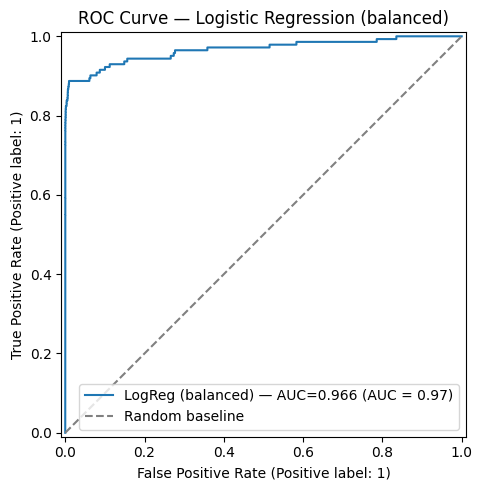

WindowsPath('../../reports/figures/week3/roc_curve_day1.png')

In [37]:
# -------------------- ROC Curve (matplotlib only) --------------------
# Υπολογισμός ROC-AUC για τίτλο/legend
roc_auc_val = roc_auc_score(y_test, y_proba)

# Δημιουργούμε figure & axis για το plot.
# figsize=(6, 5) -> ορίζει μέγεθος εικόνας (πλάτος, ύψος σε ίντσες).
fig_roc, ax_roc = plt.subplots(figsize=(6, 5))

# RocCurveDisplay: helper από sklearn που φτιάχνει καμπύλη ROC με μία γραμμή.
# - from_predictions: χρησιμοποιεί τις πραγματικές τιμές (y_test) και τις πιθανότητες (y_proba).
# - name="LogReg (balanced)": label που εμφανίζεται στο legend.
# - ax=ax_roc: σχεδιάζει στο συγκεκριμένο axis.
RocCurveDisplay.from_predictions(
    y_test, y_proba,
    name=f"LogReg (balanced) — AUC={roc_auc_val:.3f}",
    ax=ax_roc
)
# Προσθήκη baseline (τυχαίος ταξινομητής)
ax_roc.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random baseline")

# Τίτλος και legend
ax_roc.set_title("ROC Curve — Logistic Regression (balanced)", fontsize=12)
ax_roc.legend(loc="lower right")

# Καθαρή διάταξη
fig_roc.tight_layout()

# Ορισμός path για αποθήκευση
roc_path = IMAGES_DIR / "roc_curve_day1.png"

# Αποθήκευση εικόνας
fig_roc.savefig(roc_path, dpi=150, bbox_inches="tight")

# Εμφάνιση στο notebook
plt.show()

# Επιστροφή path (clickable στο Jupyter)
roc_path



Τι είναι η καμπύλη ROC
- ROC = Receiver Operating Characteristic.
- Δείχνει το True Positive Rate (recall) vs False Positive Rate για όλα τα πιθανά thresholds.
- Η διαγώνιος = τυχαία πρόβλεψη. Όσο πιο μακριά από τη διαγώνιο, τόσο καλύτερο το μοντέλο.
- Το AUC (Area Under Curve) δίνει συνολικό σκορ (0.5 = random, 1.0 = τέλειο).

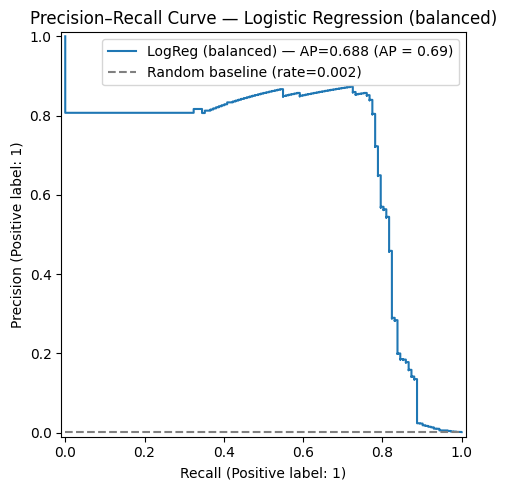

WindowsPath('../../reports/figures/week3/pr_curve_day1.png')

In [38]:
# -------------------- Precision–Recall Curve (improved) --------------------

# Υπολογισμός PR-AUC (Average Precision)
ap_val = average_precision_score(y_test, y_proba)
baseline = y_test.mean()  # baseline precision = fraud rate

# Δημιουργία figure & axis
fig_pr, ax_pr = plt.subplots(figsize=(6, 5))

# PR curve με sklearn helper
PrecisionRecallDisplay.from_predictions(
    y_test, y_proba,
    name=f"LogReg (balanced) — AP={ap_val:.3f}",
    ax=ax_pr
)

# Προσθήκη baseline precision (οριζόντια γραμμή = fraud rate)
ax_pr.hlines(y=baseline, xmin=0, xmax=1,
             colors="gray", linestyles="--",
             label=f"Random baseline (rate={baseline:.3f})")

# Τίτλος + legend
ax_pr.set_title("Precision–Recall Curve — Logistic Regression (balanced)", fontsize=12)
ax_pr.legend(loc="upper right")

# Καθαρή διάταξη
fig_pr.tight_layout()

# Ορισμός path για αποθήκευση
pr_path = IMAGES_DIR / "pr_curve_day1.png"

# Αποθήκευση εικόνας
fig_pr.savefig(pr_path, dpi=150, bbox_inches="tight")

# Εμφάνιση στο notebook
plt.show()

# Επιστροφή path
pr_path

🔎 Τι δείχνει η καμπύλη Precision–Recall

- Precision: από όσα προβλέψαμε ως fraud, πόσα ήταν όντως fraud.
- Recall: από όλα τα πραγματικά fraud, πόσα τα βρήκαμε.
- Η καμπύλη δείχνει τον συμβιβασμό μεταξύ τους για όλα τα thresholds.
- Στα imbalanced datasets, η PR curve είναι πιο κατατοπιστική από την ROC, γιατί η ROC μπορεί να φαίνεται καλή (υψηλό AUC) ακόμα κι όταν το precision είναι χαμηλό.

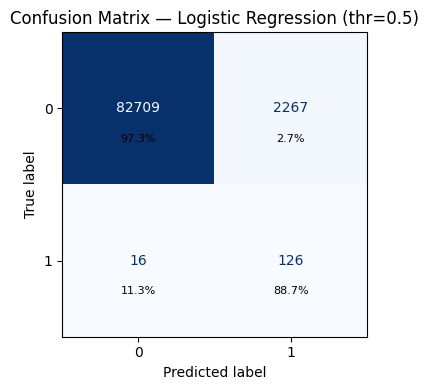

WindowsPath('../../reports/figures/week3/cm_day1.png')

In [39]:
# -------------------- Confusion Matrix (improved) --------------------

from sklearn.metrics import confusion_matrix

# Υπολογισμός confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]  # normalized per row

# Figure
fig_cm, ax_cm = plt.subplots(figsize=(5, 4))

# Visualization με ποσοστά + counts
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax_cm, cmap="Blues", values_format="d", colorbar=False)

# Εμφάνιση και normalized values (%)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax_cm.text(j, i + 0.2, f"{cm_norm[i, j]*100:.1f}%", 
                   ha="center", va="center", color="black", fontsize=8)

# Τίτλος
ax_cm.set_title("Confusion Matrix — Logistic Regression (thr=0.5)")

# Layout
fig_cm.tight_layout()

# Path αποθήκευσης
cm_path = IMAGES_DIR / "cm_day1.png"
fig_cm.savefig(cm_path, dpi=150, bbox_inches="tight")

plt.show()
cm_path


### Τι δείχνει το Confusion Matrix
- True Negatives (0 → 0): 82,709 (97.3%): Non-fraud προβλέφθηκαν σωστά ως non-fraud.
- False Positives (0 → 1): 2,267 (2.7%): Non-fraud προβλέφθηκαν λανθασμένα ως fraud (false alarms).
- False Negatives (1 → 0): 16 (11.3%): Fraud προβλέφθηκαν λανθασμένα ως non-fraud (χαμένα frauds).
- True Positives (1 → 1): 126 (88.7%): Fraud προβλέφθηκαν σωστά ως fraud.

### 📌 Συμπέρασμα:

- Έχεις υψηλό Recall (88.7%), βρίσκει σχεδόν όλα τα fraud.
- Precision είναι χαμηλότερο λόγω 2,267 FP, αλλά αυτό είναι αναμενόμενο στο baseline με class_weight="balanced".
- Αυτό το matrix είναι ήδη έτοιμο για report (π.χ. reports/week3/day1_baseline.md).


## Επόμενα βήματα (για αύριο)
- **Regularization strength (`C`) sweep** με GridSearch, κύριο metric: **PR-AUC**
- **Threshold tuning** πάνω στην καμπύλη Precision–Recall (maximize F1 ή στοχευμένο Recall)
- Αναφορά (report): σύγκριση ROC-AUC vs PR-AUC σε context **class imbalance**
